<a href="https://colab.research.google.com/github/Wajid0005/CAMPUS-X-notebooks/blob/main/Copy_of_task_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

###`Q-1:` You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.
* Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi'	'mumbai') as level-0 Index
* And Sort on row index level-0

In [4]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [5]:
df = df.unstack(level = 0).stack(level = 0).swaplevel().swaplevel(axis = 1)

/tmp/ipykernel_14423/1589654323.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.unstack(level = 0).stack(level = 0).swaplevel().swaplevel(axis = 1)


In [6]:
df.sort_index()

cse         ece      cse      ece
            avg_package avg_package students students
delhi  2019           1           9        2       10
       2020           3          11        4       12
       2021           5          13        6       14
       2022           7          15        8       16
mumbai 2019           0           0        0        0
       2020           0           0        0        0
       2021           0           0        0        0
       2022           0           0        0        0

###`Q-2:` Covid Cases Data Set Problem
 Make a DataFrame Using both Covid Dataset. With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [31]:
confirm = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTmqT3kxd0i0RUFiEnwA1Hboiunv28MeNTatZsIEqlPPB7mHrl0ttJL7utZ23_1s5FW8ZjODmB8jHIi/pub?gid=2142019845&single=true&output=csv')

deaths = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQn4nLCKIVZMw4e89YeRqgKaSAAwRFaZ6ILMW_FUejZ2tkv3Np1f9gD4QOl3ASHeLzWjOjfmLDKcCOF/pub?gid=212966958&single=true&output=csv")

In [32]:
confirm = confirm.melt(id_vars=['Province/State','Country/Region','Lat','Long'], var_name='date', value_name='num_cases')
deaths = deaths.melt(id_vars=['Province/State','Country/Region','Lat','Long'], var_name='date', value_name='num_deaths')


In [33]:
covid = pd.merge(confirm, deaths,on = ['Province/State','Country/Region','Lat','Long','date'])

In [14]:
covid.sample(4)

,Province/State,Country/Region,Lat,Long,date,num_cases,num_deaths
268379,NaN,Moldova,47.4116,28.3699,8/7/22,541715,11630
21230,NaN,Gambia,13.4432,-15.3101,4/4/20,4,1
305299,NaN,Estonia,58.5953,25.0136,12/13/22,610473,2799
67109,Chongqing,China,30.0572,107.8740,9/10/20,584,6


In [34]:
covid.set_index(['Country/Region','Province/State'], inplace=True)

In [16]:
covid

,,Lat,Long,date,num_cases,num_deaths
Country/Region,Province/State,,,,,
Afghanistan,NaN,33.939110,67.709953,1/22/20,0,0
Albania,NaN,41.153300,20.168300,1/22/20,0,0
Algeria,NaN,28.033900,1.659600,1/22/20,0,0
Andorra,NaN,42.506300,1.521800,1/22/20,0,0
Angola,NaN,-11.202700,17.873900,1/22/20,0,0
...,...,...,...,...,...,...
West Bank and Gaza,NaN,31.952200,35.233200,1/2/23,703228,5708
Winter Olympics 2022,NaN,39.904200,116.407400,1/2/23,535,0
Yemen,NaN,15.552727,48.516388,1/2/23,11945,2159


In [29]:
covid.head(2)

,,,Lat,Long,num_cases,num_deaths
Country/Region,Province/State,date,,,,
Afghanistan,NaN,1/22/20,33.93911,67.709953,0,0
Albania,NaN,1/22/20,41.15330,20.168300,0,0


In [39]:
covid[['date','num_cases', 'num_deaths']]

,,date,num_cases,num_deaths
Country/Region,Province/State,,,
Afghanistan,NaN,1/22/20,0,0
Albania,NaN,1/22/20,0,0
Algeria,NaN,1/22/20,0,0
Andorra,NaN,1/22/20,0,0
Angola,NaN,1/22/20,0,0
...,...,...,...,...
West Bank and Gaza,NaN,1/2/23,703228,5708
Winter Olympics 2022,NaN,1/2/23,535,0
Yemen,NaN,1/2/23,11945,2159


###`Q-3:` Show Country with Heighest death percent out of confirmed Cases.

In [42]:
covid['death_confirm_pct'] = covid['num_deaths'] / covid['num_cases'] * 100

In [51]:
covid_temp = covid.groupby('Country/Region').sum()


In [53]:
covid_temp['death_to_confirm'] =covid_temp['num_deaths'] / covid_temp['num_cases'] * 100

In [56]:
covid_temp.drop(columns=['death_confirm_pct'], inplace= True)


KeyError: "['death_confirm_pct'] not found in axis"

In [64]:
covid.drop(columns = ['death_confirm_pct'], inplace=True)

In [63]:
covid_temp.sort_values(by = 'death_to_confirm', ascending = False)[['num_deaths','num_cases','death_to_confirm']]

,num_deaths,num_cases,death_to_confirm
Country/Region,,,
"Korea, North",1404,234,600.000000
MS Zaandam,2014,9071,22.202624
Yemen,1372952,7091065,19.361718
Sudan,2850576,38729339,7.360250
Peru,156296296,2203724423,7.092370
...,...,...,...
Antarctica,0,4235,0.000000
Holy See,0,24893,0.000000
Summer Olympics 2020,0,441598,0.000000


### `Q-4` : Make a dataframe for India from Covid Data with one extra column representing no of new cases.

* Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
* First day new cases will be NaN or equal to no of cases

Say on 12/30/22 No of cases is - 44679608	and a day previous (12/29/22) no of cases is - 44679382.

Then for 12/30/22 -> No of New Cases  = 44679608 - 44679382 =

Note:- Try using shift Function

Try using the shift function

```
s = pd.Series([1,2,3,4,5,6])
s #-> [1,2,3,4,5,6]
s.shift(1) #-> [NaN, 1,2,3,4,5]
s.shift(-1) #-> [2,3,4,5,6, NaN]
```

In [66]:
covid.groupby('Country/Region').get_group('India')

Lat      Long      date  num_cases  \
Country/Region Province/State                                             
India          NaN             20.593684  78.96288   1/22/20          0   
               NaN             20.593684  78.96288   1/23/20          0   
               NaN             20.593684  78.96288   1/24/20          0   
               NaN             20.593684  78.96288   1/25/20          0   
               NaN             20.593684  78.96288   1/26/20          0   
...                                  ...       ...       ...        ...   
               NaN             20.593684  78.96288  12/29/22   44679382   
               NaN             20.593684  78.96288  12/30/22   44679608   
               NaN             20.593684  78.96288  12/31/22   44679873   
               NaN             20.593684  78.96288    1/1/23   44680046   
               NaN             20.593684  78.96288    1/2/23   44680180   

                               num_deaths  
Country/Region Province/State              
India          NaN                      0  
               NaN                      0  
               NaN                      0  
               NaN                      0  
               NaN                      0  
...                                   ...  
               NaN                 530699  
               NaN                 530702  
               NaN                 530705  
               NaN                 530707  
               NaN                 530707  

[1077 rows x 5 columns]

In [72]:
df =covid.groupby('Country/Region').get_group('India')

india_df = df.copy()
india_df['num_new_cases'] = india_df['num_cases'] - india_df['num_cases'].shift(1)

In [73]:
india_df

Lat      Long      date  num_cases  \
Country/Region Province/State                                             
India          NaN             20.593684  78.96288   1/22/20          0   
               NaN             20.593684  78.96288   1/23/20          0   
               NaN             20.593684  78.96288   1/24/20          0   
               NaN             20.593684  78.96288   1/25/20          0   
               NaN             20.593684  78.96288   1/26/20          0   
...                                  ...       ...       ...        ...   
               NaN             20.593684  78.96288  12/29/22   44679382   
               NaN             20.593684  78.96288  12/30/22   44679608   
               NaN             20.593684  78.96288  12/31/22   44679873   
               NaN             20.593684  78.96288    1/1/23   44680046   
               NaN             20.593684  78.96288    1/2/23   44680180   

                               num_deaths  num_new_cases  
Country/Region Province/State                             
India          NaN                      0            NaN  
               NaN                      0            0.0  
               NaN                      0            0.0  
               NaN                      0            0.0  
               NaN                      0            0.0  
...                                   ...            ...  
               NaN                 530699          243.0  
               NaN                 530702          226.0  
               NaN                 530705          265.0  
               NaN                 530707          173.0  
               NaN                 530707          134.0  

[1077 rows x 6 columns]

### `Q-5:` Read the Dataset using the below given link and create a multi-index dataframe using the columns "Country" and "City/Town".

This dataset is about the most polluted cities in the world. You can get details from [here](https://www.kaggle.com/datasets/rajkumarpandey02/worlds-most-air-polluted-countries-cities).

**Dataset link:** https://tinyurl.com/2fe6vz4u Directly use this link to read.

**Task:**
1. Find out the name of the city of India which is most poluted based on PM10.
2. Find out the name of the city of India which has minumum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [77]:
df =pd.read_csv('https://tinyurl.com/2fe6vz4u')

In [79]:
df.drop(columns=['Unnamed: 0'], inplace =True )

In [82]:
df.head()
df.set_index(['Country','City/Town'], inplace=True )

In [89]:
df.loc['India'].sort_values('PM10', ascending = False).head(1).index[0]


'Kanpur'

In [90]:
df.loc['India'].sort_values('PM10', ascending = True).head(1).index[0]


'Aizawl'

In [91]:
df.loc['India'].sort_values('PM10', ascending = True).head(1)


,Position,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
City/Town,,,,,,,
Aizawl,484,2016,27,NaN,44,NaN,2018


In [94]:
df.loc['China'].sort_values('PM10', ascending  = False).head(1).index[0]

'Jinan'

In [95]:
df.loc['China'].sort_values('PM10', ascending  = True).head(1).index[0]

'Anshun'

In [102]:
df.loc['China'].sort_values('PM10', ascending  = True)

,Position,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
City/Town,,,,,,,
Anshun,477,2016,27,NaN,38,NaN,2018
Shenzhen,482,2016,27,NaN,42,NaN,2018
Eerduosi,452,2014,28,NaN,42,NaN,2016
Putian,436,2016,29,NaN,43,NaN,2018
Zhongshan,417,2016,30,NaN,44,NaN,2018
...,...,...,...,...,...,...,...
Anyang,27,2016,86,NaN,155,NaN,2018
Linfen,52,2016,74,NaN,158,NaN,2018
Handan,34,2016,82,NaN,175,NaN,2018


<Axes: ylabel='PM10'>

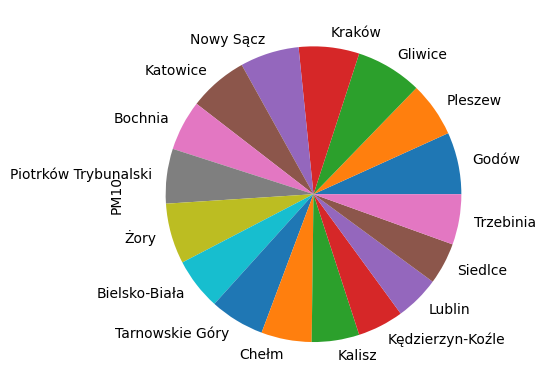

In [117]:
df.loc['Poland']['PM10'].plot(kind = 'pie')

<Axes: xlabel='Country,City/Town'>

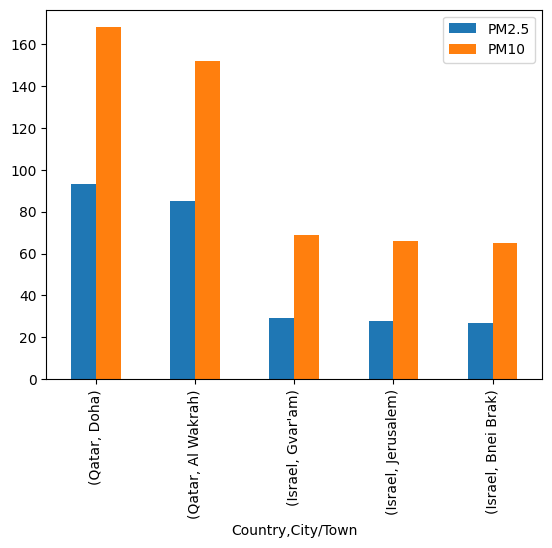

In [123]:
df.loc[['Qatar', 'Israel']][['PM2.5', 'PM10']].plot(kind = 'bar')

In [131]:
 df.stack()

Country  City/Town                         
India    Kanpur     Position                      1
                    Year                       2016
                    PM2.5                       173
                    Temporal coverage          >75%
                    PM10                        319
                                               ... 
Turkey   Sivas      PM2.5                        27
                    Temporal coverage          >75%
                    PM10                         56
                    Temporal coverage.1        >75%
                    Database version (year)    2018
Length: 2638, dtype: object